In [1]:
from scipy.io import wavfile
import numpy as np
from ml_tools.utilities import rolling_windows_nd, standardize_data
from ml_tools.models.layers.operators import LatentStack
from ml_tools.models.model_loss import MSELoss
from ml_tools.models.optimizers import SGD
from ml_tools.models.layers.layers import (
    FrequencyFFT,
    FullyConnectedLayer,
    DropoutLayer,
    NormalizeLayer,
)

from ml_tools.models.blocks import (
    FourierAttention,
    SpectreAttention)

from ml_tools.models.embedding.positional import RopeEmbedding
import matplotlib.pyplot as plt

RNG = np.random.default_rng(42)

MAX_POSSIBLE_WINDOWS = 10000
WINDOW_MS = 30


In [2]:
def read_and_process_datafile(filename: str) -> np.ndarray:

    sample_rate, waveform = wavfile.read(filename)
    time_per_sample = 1000 / sample_rate
    SAMPLES_PER_WINDOW = int(WINDOW_MS / time_per_sample)

    # Mono recoridng---
    if waveform.ndim == 1:
        target = waveform.reshape(-1, 1)
    # stereo recording---
    else:
        waveform_l, waveform_r = (
            standardize_data(waveform[:, 0]),
            standardize_data(waveform[:, 1]),
        )

        target = RNG.choice([waveform_l, waveform_r])

    windowed_data = rolling_windows_nd(
        data=target,
        window_size=SAMPLES_PER_WINDOW,
        num_overlap=SAMPLES_PER_WINDOW // 5,
        axis=0,
    )

    return windowed_data





In [4]:
import os
import pickle

WINDOW_MS = 50

all_windowed_data = []

all_filenames = os.listdir(f"../data/")
for fn in all_filenames:
    if fn.endswith(".wav"):
        array = read_and_process_datafile(f"../data/{fn}")
    else:
        continue

    # all_windowed_data.append({fn: array})
    # filenames too long
    all_windowed_data.append(array)

with open(f"../data/windowed_data.pkl", "wb") as f:
    pickle.dump(all_windowed_data, f)


In [5]:
for arr in all_windowed_data:
    print(arr.shape)

(114, 200, 1)
(158, 200, 1)
(179, 200, 1)
(143, 200, 1)
(107, 200, 1)
(109, 200, 1)
(186, 200, 1)
(87, 200, 1)
(160, 200, 1)
(169, 200, 1)
(113, 200, 1)
(175, 200, 1)
(160, 200, 1)
(129, 200, 1)
(188, 200, 1)
(171, 200, 1)
(137, 200, 1)
(218, 200, 1)
(130, 200, 1)
(181, 200, 1)
(197, 200, 1)
(147, 200, 1)
(116, 200, 1)
(131, 200, 1)
(140, 200, 1)
(145, 200, 1)
(171, 200, 1)
(195, 200, 1)
(181, 200, 1)
(172, 200, 1)
(121, 200, 1)
(129, 200, 1)
(166, 200, 1)
(190, 200, 1)
(127, 200, 1)
(165, 200, 1)
(136, 200, 1)
(115, 200, 1)
(129, 200, 1)
(99, 200, 1)
(141, 200, 1)
(150, 200, 1)
(139, 200, 1)
(140, 200, 1)
(89, 200, 1)
(185, 200, 1)
(143, 200, 1)
(179, 200, 1)
(135, 200, 1)
(148, 200, 1)
(174, 200, 1)
(137, 200, 1)
(160, 200, 1)
(94, 200, 1)
(169, 200, 1)
(181, 200, 1)
(194, 200, 1)
(156, 200, 1)
(164, 200, 1)
(135, 200, 1)
(87, 200, 1)
(93, 200, 1)
(188, 200, 1)
(110, 200, 1)
(133, 200, 1)
(132, 200, 1)
(220, 200, 1)
(152, 200, 1)
(2344, 200, 1)
(181, 200, 1)
(166, 200, 1)
(80, 200, 1

/var/folders/2v/nxc1f8bj0zg_qz_5lqd0w34r0000gn/T/ipykernel_1124/2237064165.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, waveform = wavfile.read(


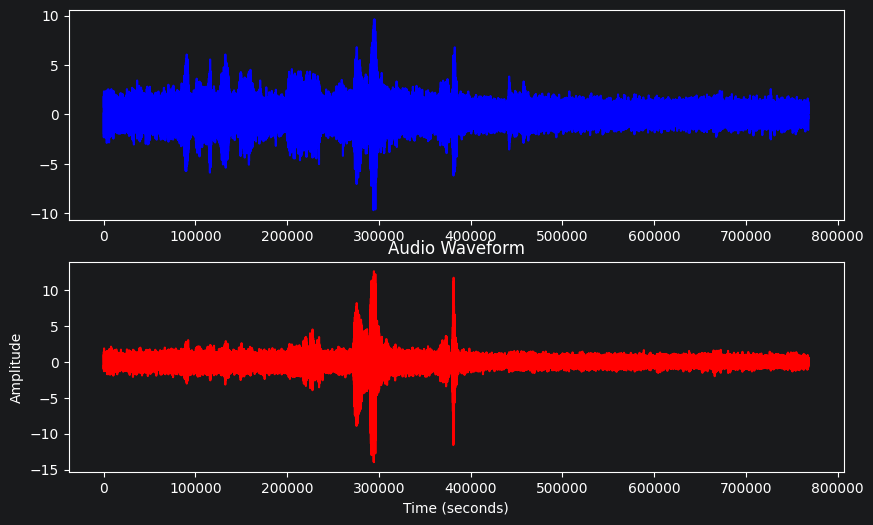

In [6]:
sample_rate, waveform = wavfile.read(
    "/Users/davidanderson/Dropbox/CODE/tools/ml-tools/test.wav"
)

waveform_l, waveform_r = (
    standardize_data(waveform[:, 0]),
    standardize_data(waveform[:, 1]),
)

num_samples = waveform.shape[0]

xs = np.arange(0, num_samples)
plt.figure(figsize=(10, 6))
plt.subplot(2, 1, 1)
plt.plot(xs, waveform_l, color="blue")
plt.subplot(2, 1, 2)
plt.plot(xs, waveform_r, color="red")
plt.title("Audio Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()


In [ ]:
import numpy as np
import pywt


def dwt_single_window(
    x: np.ndarray,
    levels: int = 3,
    wavelet: str = "haar"
):
    """
    Apply multi-level DWT to a single 1D signal.

    Parameters
    ----------
    x : 1D numpy array
    levels : number of decomposition levels
    wavelet : wavelet type (default: 'haar')

    Returns
    -------
    coeffs : list
        [cA_L, cD_L, cD_{L-1}, ..., cD_1]
    """

    coeffs = pywt.wavedec(
        data=x,
        wavelet=wavelet,
        level=levels,
        mode="symmetric"
    )

    return coeffs


def dwt_windows(
    incoming_x: np.ndarray,
    levels: int = 3,
    wavelet: str = "haar"
):
    """
    Apply multi-level DWT to windowed input.

    Parameters
    ----------
    incoming_x : shape (num_windows, window_size)

    Returns
    -------
    List of wavelet coefficient lists per window
    """

    outputs = []

    for window in incoming_x:
        coeffs = pywt.wavedec(
            data=window,
            wavelet=wavelet,
            level=levels,
            mode="symmetric"
        )
        outputs.append(coeffs)

    return outputs


def plot_wavelet_spectrogram(
    signal: np.ndarray,
    levels: int = 4,
    wavelet: str = "haar",
    log_scale: bool = True
):
    """
    Plot wavelet spectrogram (time–scale energy map) for a single 1D signal.

    Parameters
    ----------
    signal : 1D numpy array
    levels : number of decomposition levels
    wavelet : wavelet type (default: 'haar')
    log_scale : whether to apply log scaling to energy
    """

    assert signal.ndim == 1, "input must be a 1D signal"

    # Stationary Wavelet Transform (no downsampling)
    coeffs = pywt.swt(
        data=signal,
        wavelet=wavelet,
        level=levels
    )

    # coeffs format:
    # [(cA_L, cD_L), ..., (cA_1, cD_1)]
    energy_map = []

    for level_idx, (cA, cD) in enumerate(coeffs):
        energy = cD ** 2
        energy_map.append(energy)

    energy_map = np.array(energy_map)

    if log_scale:
        energy_map = np.log1p(energy_map)

    energy_map = energy_map / np.mean(energy_map)
    # Plot
    fig, axes = plt.subplots(2, 1, sharex=True)

    img = axes[0].imshow(
        energy_map,
        aspect="auto",
        origin="lower",
        cmap="cividis",
    )

    axes[0].set_xlabel("time")
    axes[0].set_ylabel("wavelet scale (level)")
    axes[0].set_title("wavelet spectrogram (time energy)")
    fig.colorbar(img, ax=axes[0], label="energy")

    axes[1].plot(signal)
    fig.colorbar(img, ax=axes[1], label="energy")
    plt.tight_layout()
    plt.show()


In [ ]:
wavelet_transform = dwt_single_window(waveform_l, levels=4, wavelet="haar")

In [ ]:
%%timeit
spec = plot_wavelet_spectrogram(waveform_l, levels=2, wavelet="haar",
                                log_scale=True)

In [ ]:
time_per_sample = 1000 / sample_rate
print(time_per_sample, "ms per sample step")

# set window size as ms length ---
window_ms = 50

samples_per_window = int(window_ms / time_per_sample)
print(f"Each {window_ms} ms window will be composed of {samples_per_window} samples")



time_axis = np.arange(windowed_decibel_spectrogram.shape[0])

idx = 55
fig, axes = plt.subplots(1, 1, sharex=True)
img = axes.pcolormesh(time_axis, freqs[:], win# now we take windows --
windowed_data = rolling_windows_nd(
    data=waveform_l,
    window_size=samples_per_window,
    num_overlap=samples_per_window // 5,
    axis=0,
)

# window count, sample_steps
num_windows, _samp = windowed_data.shape
assert _samp == samples_per_window


windowed_spectrogram = []
window = np.blackman(samples_per_window)
# junky workaround so we don't have to fancy-reindex.
for i in range(num_windows):
    start, end = i * samples_per_window, (i * samples_per_window + samples_per_window)
    # junky workaround so we don't have to fancy-reindex.
    if end > waveform_l.size:
        break

    kernel = waveform_l[start:end] * window

    xs = np.fft.rfft(kernel)
    magnitude = np.abs(xs)
    windowed_spectrogram.append(magnitude)

windowed_spectrogram = np.vstack(windowed_spectrogram)


freqs = np.fft.rfftfreq(samples_per_window, d=1.0 / sample_rate)
# magnitude = np.abs(windowed_data) / samples_per_window
# square all except DC (0 idx and representing zero hertz) and Nyquist (-1 position)
power_spectrogram = windowed_spectrogram.copy() / np.mean(windowed_spectrogram)
power_spectrogram[:, 1:-1] = power_spectrogram[:, 1:-1] ** 2
# square to power, log to decibels (log10?)
windowed_decibel_spectrogram = np.log1p(power_spectrogram + 1e-12)dowed_decibel_spectrogram.T,
                         cmap="cividis", shading="auto")
axes.set_xlabel("Time")
axes.set_ylabel("Frequency")
axes.set_title("Spectrogram (RFFT)")
fig.colorbar(img, ax=axes, label="Energy")
plt.show()

fig, axes = plt.subplots(3, 1, sharex=True)
axes[0].set_title(f"window index{idx}")
axes[0].plot(freqs, windowed_spectrogram[idx, :])
axes[0].set_xlabel("Frequency Hz")
axes[0].set_ylabel("amplitude")
axes[0].set_title("RFFT frequency spectrum")
fig.colorbar(img, ax=axes[0], label="Energy")

axes[1].plot(freqs, power_spectrogram[idx, :])
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("power")
axes[1].set_title("RFFT Power Spectrum")
fig.colorbar(img, ax=axes[1], label="Energy")

axes[2].semilogy(freqs, windowed_decibel_spectrogram[idx, :])
axes[2].set_xlabel("Frequency (Hz)")
axes[2].set_ylabel("amplitude (log)")
axes[2].set_title("RFFT Log Spectrum")
fig.colorbar(img, ax=axes[2], label="Energy")

plt.tight_layout()
plt.show()


In [ ]:
%%timeit
spec = plot_wavelet_spectrogram(waveform_l, levels=4, wavelet="haar",log_scale=True)

In [ ]:
spec = plot_wavelet_spectrogram(waveform_l, levels=6, wavelet="haar",
                                log_scale=True)

In [ ]:
spec = plot_wavelet_spectrogram(waveform_l, levels=8, wavelet="haar",
                                log_scale=True)

In [ ]:
fig, axes = plt.subplots(2, 1, sharex=True)

img = axes[0].pcolormesh(time_axis, freqs, windowed_decibel_spectrogram.T,
                         cmap="cividis")
plt.show()

In [ ]:
outs = dwt_windows(windowed_data)
outs

In [ ]:
#  FFT will output a shape of n//2 + 1.
real_positive_fft_shape = (samples_per_window // 2) + 1

# project dimensions down to half - this should be enough to keep our calculations
# limited without losing too much grainularity in the data.
LATENT_DIMENSION = int(real_positive_fft_shape * 0.75)


# AMPLITUDE ------------------------------------------------------------------
# FUNNEL PROJECTION -->
# dimensional reduction in Feed Forward, built of 1-4 stacked layers
# this gives us a weighted amplitude
# Project down to real_positive_fft_shape? OR LATENT_DIMENSION
# (1920, 1080,   real_positive_fft_shape)
amplitude_layer_a = FullyConnectedLayer(
    ni=samples_per_window, no=1200, activation_type="relu", is_output=False
)
amplitude_layer_b = FullyConnectedLayer(
    ni=1200, no=real_positive_fft_shape, activation_type="relu",
    is_output=False
)
amplitude_layer_c = FullyConnectedLayer(
    ni=real_positive_fft_shape,
    no=LATENT_DIMENSION,
    activation_type="tanh",
    is_output=True,
)


# FREQUENCY -----------------------------------------------------------------
# real positive only FFT: np rfft process -> final shape of FFT transform is  n//2 + 1.
# transformed_data = np.fft.rfft(windowed_data, axis=-1)
freq_fft_layer = FrequencyFFT(
    max_sequence_length=MAX_POSSIBLE_WINDOWS, window_size=samples_per_window
)
freq_fc_layer = FullyConnectedLayer(
    ni=real_positive_fft_shape,
    no=LATENT_DIMENSION,
    activation_type="tanh",
    is_output=True,
)

# Feed Forward, built of 1-3 stacked layers?
stacking_layer = LatentStack()

# Rotary Positional embedding - (relative position and distances -------------
rope_layer = RopeEmbedding(
    sequence_length=MAX_POSSIBLE_WINDOWS, embedding_dimension=2 * LATENT_DIMENSION
)

# enc_attention = FourierAttention(
#     ni=2 * LATENT_DIMENSION, no=2 * LATENT_DIMENSION, use_2d=True
# )

enc_attention = SpectreAttention(
    sequence_length=num_windows,
    hidden_dim=2 * LATENT_DIMENSION
)


EMBEDDING_DIM = 720
# feed froward--
FC_IN = 2 * LATENT_DIMENSION
dropout_a = DropoutLayer(dropout_prob=0.05)
fc_a = FullyConnectedLayer(ni=FC_IN, no=1200, activation_type="relu",
                           is_output=False)
fc_b = FullyConnectedLayer(ni=1200, no=900, activation_type="relu",
                           is_output=False)
fc_c = FullyConnectedLayer(
    ni=900, no=EMBEDDING_DIM, activation_type="tanh", is_output=False
)


# And Finally, we're at the latent space embedding ------------------------
# NOW WE CAN SEND THE LATENT EMBEDDING INTO our Kernel FourierNetwork.
# the feature encoding and Kernel FourierNetwork layers out into the model's embedding - latent space.

decoder_dropout = DropoutLayer(dropout_prob=0.05)
# decoder_attention = FourierAttention(ni=EMBEDDING_DIM, no=EMBEDDING_DIM, use_2d=True)

decoder_attention = SpectreAttention(
    sequence_length=num_windows,
    hidden_dim=LATENT_DIMENSION
)

decoder_fc_a = FullyConnectedLayer(
    ni=EMBEDDING_DIM, no=1200, activation_type="relu", is_output=False
)
decoder_fc_b = FullyConnectedLayer(
    ni=1200, no=samples_per_window, activation_type="relu", is_output=False
)
decoder_norm = NormalizeLayer(ni=samples_per_window, shift_scale=True)

# rescaling layer
decoder_fc_c = FullyConnectedLayer(
    ni=samples_per_window,
    no=samples_per_window,
    activation_type="linear",
    is_output=True,
)

loss = MSELoss()
optimizer = SGD(1e-4)
# assert (decoder_output.shape == (num_windows, samples_per_window))
# REBUILD windowed_data
# reconstruction error = winodw_data - decoder output


# now let's do some fitting ---
all_losses = []
all_layers = [amplitude_layer_a, amplitude_layer_b, amplitude_layer_c, freq_fft_layer, freq_fc_layer,
              stacking_layer, rope_layer, enc_attention, dropout_a, fc_a, fc_b, fc_c, decoder_dropout,
              decoder_attention, decoder_fc_a, decoder_fc_b, decoder_norm, decoder_fc_c,]

In [ ]:
print(windowed_data.shape)
windowed_data = windowed_data.reshape(-1, windowed_data.shape[0],
                                      windowed_data.shape[1])

# windowed_data = windowed_data.reshape(-1,
#                                       windowed_data.shape[-1])
print(windowed_data.shape)

# Training ----


In [ ]:
%pdb on
print(windowed_data.shape)
for step in range(50):
    verbose = True if (step + 1) % 3 == 0 else False
    # verbose = True

    # -------------------- FORWARD PASS THROUGH THE NETWORK ------------
    x_amp = amplitude_layer_c(amplitude_layer_b(amplitude_layer_a(windowed_data)))
    x_freq = freq_fc_layer(freq_fft_layer(windowed_data))
    if verbose:
        print(f"amp shape:  {x_amp.shape} freq shape: {x_freq.shape}")
    stacked = stacking_layer(x_amp, x_freq)
    if verbose:
        print(f"stacked shape:  {stacked.shape}")
    x_stacked = rope_layer(stacked)
    if verbose:
        print(f"Rope shape:  {x_stacked.shape}")
    encoded = fc_c(fc_b(fc_a(dropout_a(enc_attention(x_stacked)))))
    if verbose:
        print("latent encoding is shape: ", encoded.shape)

    x_prime = decoder_fc_c(
        decoder_norm(
            decoder_fc_b(
                decoder_fc_a(
                    decoder_attention(
                        decoder_dropout(encoded))))
        )
    )

    _l = loss.forward(prediction=x_prime, targets=windowed_data)
    all_losses.append(_l.item())

    if verbose:
        print(f"x prime shape: {x_prime.shape}")
        print(
            f"at this stage, we've output a model recreation of encoder-decoder process."
            f" x_prime (model output) is {x_prime.shape} compared to the original {windowed_data.shape}"
        )
        print(f"reconstruction loss is at {_l}")

        to_plot = x_prime[0, idx, :].copy().reshape(-1, 1920)
        to_plot = np.fft.rfft(to_plot)
        to_plot[:, 1:-1] = to_plot[:, 1:-1] ** 2
        ys = windowed_data[0, idx, :].copy().reshape(-1, 1920)
        ys = np.fft.rfft(ys)
        ys[:, 1:-1] = ys[:, 1:-1] ** 2
        plt.subplot(1,2,1)
        plt.plot(freqs, standardize_data(to_plot.squeeze()), color="blue")
        plt.subplot(1,2,2)
        plt.plot(freqs, standardize_data(ys.squeeze()), color="yellow")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("power")
        plt.title("RFFT Power Spectrum")
        plt.show()
    # -------------------- backwards pass --------------------
    grad_output = loss.backward()

    grad_output = decoder_dropout.backward(
        decoder_attention.backward(
            decoder_fc_a.backward(
                decoder_fc_b.backward(
                    decoder_norm.backward(
                        decoder_fc_c.backward(grad_output)
                    )
                )
            )
        )
    )
    if verbose:
        print(f"decoder_net backpass {grad_output.shape}")

    grad_output = enc_attention.backward(
        dropout_a.backward(
            fc_a.backward(
                fc_b.backward(
                    fc_c.backward(grad_output)
                )
            )
        )
    )
    if verbose:
        print(f"embedding_net backpass {grad_output.shape}")
    grad_output = rope_layer.backward(grad_output)
    if verbose:
        print(f"rope_layer backpass {grad_output.shape}")
    amp_grad, freq_grad = stacking_layer.backward(grad_output)
    if verbose:
        print(f"stacking backpass {amp_grad.shape}, freq_grad.shape")

    amp_grad = amplitude_layer_c.backward(amp_grad)
    amp_grad = amplitude_layer_b.backward(amp_grad)
    amp_grad = amplitude_layer_a.backward(amp_grad)
    freq_out = freq_fft_layer.backward(freq_fc_layer.backward(freq_grad))

    optimizer.step(all_layers)

    if verbose:
        plt.plot(all_losses)
        plt.show()

print(all_losses)
plt.plot(all_losses)
plt.show()

In [ ]:
windowed_data.ndim
